<a href="https://colab.research.google.com/github/akash-gupta06/Savita-Kitchen-Ecommerce-Sales-Analysis/blob/main/SK_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
## importing libraries
import pandas as pd
import glob


In [67]:
#taking all files from the folder
all_files = glob.glob("/content/Sales-data/*.csv")

In [68]:
#now concating all the csv files
sales_data= pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

In [69]:
sales_data.shape

(12840, 78)

In [70]:
type(sales_data['Order Date'])

pandas.core.series.Series

In [71]:
#converting order date to datetime format so that i can do soting
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], errors="coerce")


In [72]:
# Sort descending: May 2026 -> Jan 2022
sales_data = sales_data.sort_values(by="Order Date", ascending=False).reset_index(drop=True)

In [73]:
# Save sorted file
sales_data.to_csv("Sales-data-sorted.csv", index=False)

In [74]:
len(sales_data)

12840

In [75]:
sales_data.head()

,Seller Gstin,Invoice Number,Invoice Date,Transaction Type,Order Id,Shipment Id,Shipment Date,Order Date,Shipment Item Id,Quantity,...,Tcs Sgst Amount,Tcs Utgst Rate,Tcs Utgst Amount,Tcs Igst Rate,Tcs Igst Amount,Warehouse Id,Fulfillment Channel,Payment Method Code,Credit Note No,Credit Note Date
0,22FFQPD2163M1ZA,IN-259,2026-05-31 08:44:45,Shipment,406-9020136-5923547,A06472792LZDPNCMFNFWH,2026-06-01 16:03:29,2026-05-31 08:30:42,565109054617,2,...,0.0,0,0,0.000,0.00,NaN,MFN,CC,NaN,NaN
1,22FFQPD2163M1ZA,IN-258,2026-05-31 06:11:38,Shipment,407-7639201-4037938,A006893628M7P3TWRJY25,2026-06-01 16:03:35,2026-05-31 05:58:14,564879650677,1,...,0.0,0,0,0.005,1.42,NaN,MFN,COD,NaN,NaN
2,22FFQPD2163M1ZA,IN-257,2026-05-31 03:00:27,Shipment,408-5414094-4483505,A04833853R03JMPG2XQW8,2026-06-01 16:03:33,2026-05-31 02:50:04,565033458967,1,...,0.0,0,0,0.005,2.38,NaN,MFN,CC,NaN,NaN
3,22FFQPD2163M1ZA,IN-256,2026-05-30 21:10:22,Shipment,403-7836184-2212354,A0350532NWS4IQALSPDV,2026-06-01 16:03:29,2026-05-30 20:59:38,565016331996,1,...,0.0,0,0,0.005,1.42,NaN,MFN,CC,NaN,NaN
4,22FFQPD2163M1ZA,IN-255,2026-05-30 21:04:49,Shipment,405-7935201-1501965,A03457722FGYGUMVGT4UT,2026-06-01 16:03:31,2026-05-30 20:54:21,565094079575,1,...,0.0,0,0,0.005,1.42,NaN,MFN,CC,NaN,NaN


In [76]:
### Now Data Cleaning

In [77]:
## Droping irrelevent columns
sales_data.columns.tolist()

['Seller Gstin',
 'Invoice Number',
 'Invoice Date',
 'Transaction Type',
 'Order Id',
 'Shipment Id',
 'Shipment Date',
 'Order Date',
 'Shipment Item Id',
 'Quantity',
 'Item Description',
 'Asin',
 'Hsn/sac',
 'Sku',
 'Product Tax Code',
 'Bill From City',
 'Bill From State',
 'Bill From Country',
 'Bill From Postal Code',
 'Ship From City',
 'Ship From State',
 'Ship From Country',
 'Ship From Postal Code',
 'Ship To City',
 'Ship To State',
 'Ship To Country',
 'Ship To Postal Code',
 'Invoice Amount',
 'Tax Exclusive Gross',
 'Total Tax Amount',
 'Cgst Rate',
 'Sgst Rate',
 'Utgst Rate',
 'Igst Rate',
 'Compensatory Cess Rate',
 'Principal Amount',
 'Principal Amount Basis',
 'Cgst Tax',
 'Sgst Tax',
 'Igst Tax',
 'Utgst Tax',
 'Compensatory Cess Tax',
 'Shipping Amount',
 'Shipping Amount Basis',
 'Shipping Cgst Tax',
 'Shipping Sgst Tax',
 'Shipping Utgst Tax',
 'Shipping Igst Tax',
 'Shipping Cess Tax Amount',
 'Gift Wrap Amount',
 'Gift Wrap Amount Basis',
 'Gift Wrap Cgst Ta

In [78]:
## keeping only the relevent columns
columns_to_keep = [
    "Transaction Type",
    "Order Date",
    "Order Id",
    "Sku",
    "Item Description",
    "Quantity",
    "Invoice Amount",
    "Principal Amount",
    "Total Tax Amount",
    "Ship To City",
    "Ship To State",
    "Ship To Postal Code"
]

In [79]:
sales_data = sales_data[columns_to_keep]

In [80]:
sales_data.head()

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006


In [81]:
sales_data.shape

(12840, 12)

In [82]:
## Checking for Null values
sales_data.isnull().sum()

,0
Transaction Type,0
Order Date,2080
Order Id,0
Sku,0
Item Description,2080
Quantity,0
Invoice Amount,0
Principal Amount,0
Total Tax Amount,0
Ship To City,0


In [83]:
# no duplicate values
sales_data.duplicated().sum()

np.int64(0)

In [84]:
sales_data[sales_data.duplicated()]

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code


In [85]:
sales_data['Transaction Type'].unique()

array(['Shipment', 'Refund', 'Cancel'], dtype=object)

In [86]:
# diving all the data in 3 segments - Shipment, Refund, cancel

shipment_df = sales_data[sales_data['Transaction Type']=="Shipment"].copy()

In [87]:
shipment_df.shape

(9974, 12)

In [88]:
cancel_df= sales_data[sales_data['Transaction Type']=="Cancel"].copy()

In [89]:
cancel_df.shape

(2080, 12)

In [90]:
refund_df= sales_data[sales_data['Transaction Type']=="Refund"].copy()

In [91]:
refund_df.shape

(786, 12)

In [92]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006
...,...,...,...,...,...,...,...,...,...,...,...,...
10755,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101
10756,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024
10757,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123
10758,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504


In [93]:
shipment_df.dtypes

,0
Transaction Type,object
Order Date,datetime64[ns]
Order Id,object
Sku,object
Item Description,object
Quantity,int64
Invoice Amount,float64
Principal Amount,float64
Total Tax Amount,float64
Ship To City,object


In [94]:
# Now Slicing with Order date column so that i can get month and year cloums
shipment_df["Order Date"] = shipment_df["Order Date"].astype(str)


In [95]:
shipment_df['Month']= shipment_df['Order Date'].str.split('-').str[1]

In [96]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10755,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101,01
10756,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024,01
10757,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123,01
10758,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504,01


In [97]:
shipment_df['Year']= shipment_df['Order Date'].str.split('-').str[0]

In [98]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05,2026
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05,2026
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05,2026
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05,2026
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10755,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101,01,2022
10756,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024,01,2022
10757,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123,01,2022
10758,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504,01,2022


In [99]:
shipment_df.shape

(9974, 14)

Analysing Monthly Sales

In [100]:
shipment_df.columns

Index(['Transaction Type', 'Order Date', 'Order Id', 'Sku', 'Item Description',
       'Quantity', 'Invoice Amount', 'Principal Amount', 'Total Tax Amount',
       'Ship To City', 'Ship To State', 'Ship To Postal Code', 'Month',
       'Year'],
      dtype='object')

In [101]:
shipment_df['Sales']=shipment_df['Quantity']*shipment_df['Invoice Amount']

In [102]:
shipment_df.shape

(9974, 15)

In [103]:
shipment_df.head()

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05,2026,1996.0
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05,2026,299.0
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05,2026,499.0
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05,2026,299.0
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05,2026,299.0


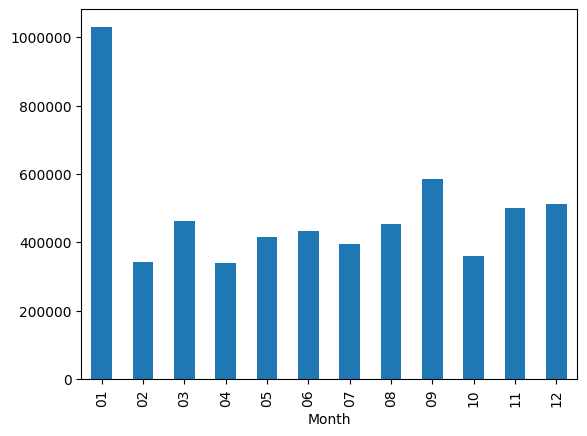

In [104]:
#Ploting Month vs Sales chart
import matplotlib.pyplot as plt
shipment_df.groupby("Month")['Sales'].sum().plot(kind= "bar")
plt.ticklabel_format(style="plain", axis='y')

Which city has maximum orders


In [107]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05,2026,1996.0
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05,2026,299.0
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05,2026,499.0
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05,2026,299.0
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05,2026,299.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10755,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101,01,2022,319.0
10756,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024,01,2022,319.0
10757,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123,01,2022,319.0
10758,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504,01,2022,319.0


In [108]:
shipment_df['Ship To Postal Code'].unique()

array([411045, 560008, 400615, ..., 223101, 281504, 700037])

In [109]:
pd.value_counts(shipment_df['Ship To Postal Code'])

/tmp/ipykernel_1743/1556225970.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(shipment_df['Ship To Postal Code'])


,count
Ship To Postal Code,
201301,100
560100,83
560066,78
560068,70
560037,69
...,...
140604,1
602105,1
491661,1


In [112]:
pincode_df= pd.read_csv("/content/all_india_pincode_directory_2025.csv")

In [113]:
# Keeping only what we need, and get ONE row per pincode (district + state)
pincode_map = pincode_df[["pincode", "district", "statename"]].drop_duplicates(subset="pincode")

In [115]:
pincode_map.isnull().sum()

,0
pincode,0
district,120
statename,120


In [116]:
# Merge on postal code
shipment_df = shipment_df.merge(
    pincode_map,
    left_on="Ship To Postal Code",
    right_on="pincode",
    how="left"
)

In [118]:
shipment_df.shape

(9974, 18)

In [119]:
shipment_df.isnull().sum()

,0
Transaction Type,0
Order Date,0
Order Id,0
Sku,0
Item Description,0
Quantity,0
Invoice Amount,0
Principal Amount,0
Total Tax Amount,0
Ship To City,0


In [121]:
#very samll null values that can be neglected
round(shipment_df['district'].isnull().sum()/len(shipment_df)*100, 2)

np.float64(1.2)

In [122]:
shipment_df['district'].unique()

array(['PUNE', 'BENGALURU URBAN', 'THANE', 'KOLKATA', 'VADODARA',
       'MURSHIDABAD', 'JAIPUR', 'CENTRAL', 'SOUTH', 'NADIA', 'LUDHIANA',
       'GAUTAM BUDDHA NAGAR', 'UDUPI', 'PATNA', 'WEST SINGHBHUM',
       'MUMBAI SUBURBAN', 'VARANASI', 'PAKUR', 'NARSINGHPUR', 'NORTH GOA',
       'RAIGAD', 'CUTTACK', 'NANDURBAR', 'GUNTUR', 'SIDDHARTH NAGAR',
       'RANCHI', 'BALLIA', 'TUMAKURU', 'GURUGRAM', 'KOTA', 'JAMNAGAR',
       'BHOJPUR', 'KHORDHA', 'DAMAN', 'BELAGAVI', 'NIZAMABAD',
       'FARIDABAD', 'RAJNANDGAON', 'SINGRAULI', 'HYDERABAD', 'SRIKAKULAM',
       'NORTH WEST', 'DEOGHAR', 'JALGAON', 'JAJAPUR', 'COIMBATORE',
       'JHANSI', 'SHEOPUR', 'NALANDA', 'PURI', 'LUCKNOW', 'ROHTAS',
       '24 PARAGANAS NORTH', 'DAKSHINA KANNADA', 'MEDINIPUR EAST',
       'SURAT', 'SANGAREDDY', 'NEW DELHI', 'SULTANPUR', 'INDORE',
       'MADHUBANI', 'CHENNAI', '24 PARAGANAS SOUTH', 'MEDCHAL MALKAJGIRI',
       'KAMAREDDY', 'CHHATARPUR', 'JAMUI', 'KAMRUP METRO', 'SOUTH WEST',
       'AIZAWL', 'WEST',

In [123]:
pd.value_counts(shipment_df['district'])

/tmp/ipykernel_1743/1452629181.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(shipment_df['district'])


,count
district,
BENGALURU URBAN,1070
PUNE,413
MUMBAI SUBURBAN,402
GAUTAM BUDDHA NAGAR,344
THANE,340
...,...
Mahisagar,1
SHEOHAR,1
Kasganj,1


Best chart: Horizontal Bar Chart (Top 10-15)
This is the standard for ranked categorical data with many categories — easier to read city names than a vertical bar chart.

In [124]:
city_orders= shipment_df['district'].value_counts().reset_index()

In [139]:
city_orders

,City,Order_Count
0,BENGALURU URBAN,1070
1,PUNE,413
2,MUMBAI SUBURBAN,402
3,GAUTAM BUDDHA NAGAR,344
4,THANE,340
...,...,...
549,Mahisagar,1
550,SHEOHAR,1
551,Kasganj,1
552,KANCHIPURAM,1


In [126]:
city_orders.columns = ["City", "Order_Count"]

In [128]:
top_15 = city_orders.head(15)

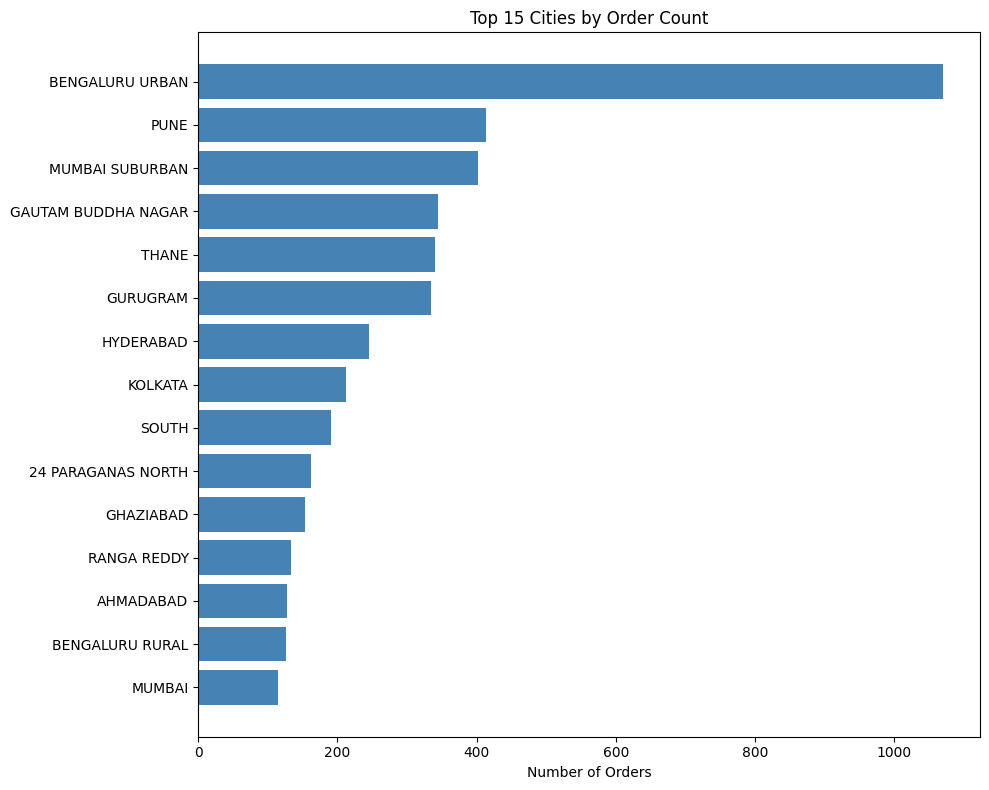

In [129]:
plt.figure(figsize=(10, 8))
plt.barh(top_15["City"], top_15["Order_Count"], color="steelblue")
plt.gca().invert_yaxis()  # highest at top
plt.xlabel("Number of Orders")
plt.title("Top 15 Cities by Order Count")
plt.tight_layout()
plt.show()

Which State has Maximum orders

In [130]:
shipment_df['statename'].unique()

array(['MAHARASHTRA', 'KARNATAKA', 'WEST BENGAL', 'GUJARAT', 'RAJASTHAN',
       'DELHI', 'PUNJAB', 'UTTAR PRADESH', 'BIHAR', 'JHARKHAND',
       'MADHYA PRADESH', 'GOA', 'ODISHA', 'ANDHRA PRADESH', 'HARYANA',
       'THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 'TELANGANA',
       'CHHATTISGARH', 'TAMIL NADU', 'ASSAM', 'MIZORAM', 'MEGHALAYA',
       'KERALA', 'UTTARAKHAND', 'HIMACHAL PRADESH', nan,
       'JAMMU AND KASHMIR', 'SIKKIM', 'PUDUCHERRY',
       'ANDAMAN AND NICOBAR ISLANDS', 'CHANDIGARH', 'TRIPURA',
       'ARUNACHAL PRADESH', 'NAGALAND', 'MANIPUR', 'LADAKH'], dtype=object)

In [132]:
state_orders= shipment_df['statename'].value_counts().reset_index()

In [133]:
state_orders.columns = ["State", "Order_Count"]

In [134]:
top_15_state = state_orders.head(15)

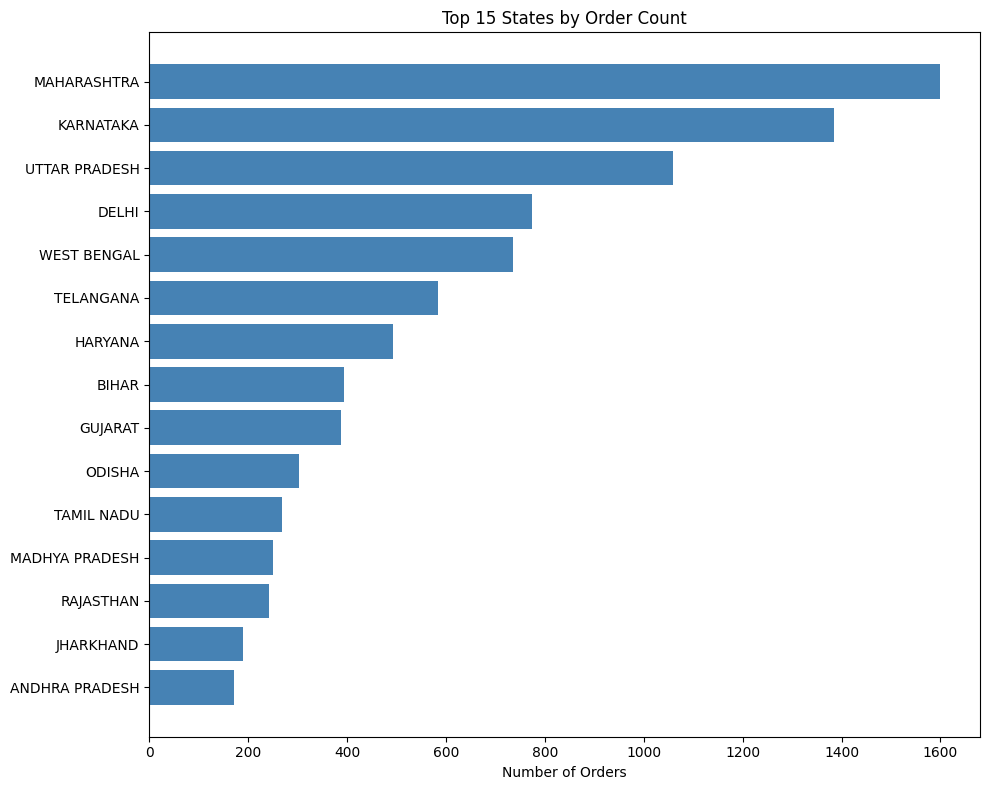

In [135]:
plt.figure(figsize=(10, 8))
plt.barh(top_15_state["State"], top_15_state["Order_Count"], color="steelblue")
plt.gca().invert_yaxis()  # highest at top
plt.xlabel("Number of Orders")
plt.title("Top 15 States by Order Count")
plt.tight_layout()
plt.show()

What Product Sold the most and Why?

In [151]:
sku_new = shipment_df['Sku'].value_counts().reset_index().head(60)

In [153]:
sku_new

,Sku,count
0,BTil400,1495
1,MN500,924
2,TP,680
3,BTil800,677
4,ThekuaA,645
5,ER-NIK9-GEAS,625
6,WTil400,429
7,AN500,338
8,WTil800,291
9,Aam400,267


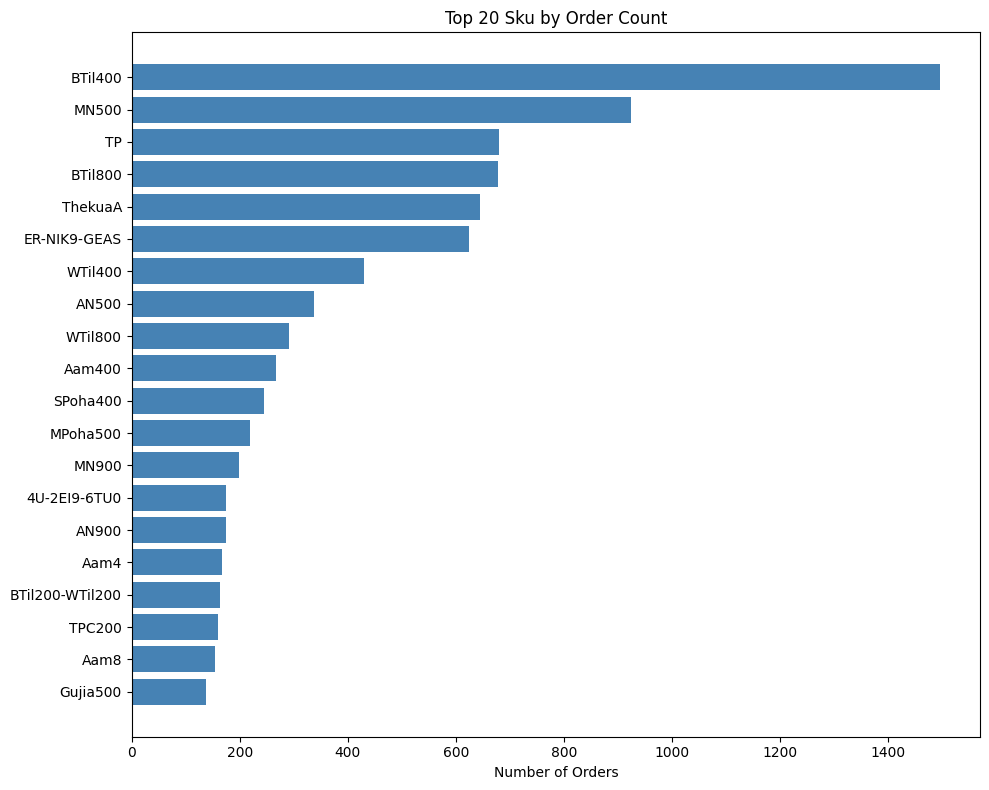

In [156]:
sku_new.columns = ["Sku", "Order_Count"]
top_20_sku = sku_new.head(20)
plt.figure(figsize=(10, 8))
plt.barh(top_20_sku["Sku"], top_20_sku["Order_Count"], color="steelblue")
plt.gca().invert_yaxis()  # highest at top
plt.xlabel("Number of Orders")
plt.title("Top 20 Sku by Order Count")
plt.tight_layout()
plt.show()

In [155]:
shipment_df.groupby(['Sku']).agg({'Quantity':'sum', 'Invoice Amount': 'mean'})

,Quantity,Invoice Amount
Sku,,
400AMLA,1,299.000000
400TSR,10,349.000000
4U-2EI9-6TU0,183,367.491437
6C-CIHQ-373L,3,399.000000
800Amla,6,499.000000
...,...,...
Tisi400g,97,429.255556
Tisi800,41,701.685714
WTil400,458,351.893217


Analysing Monthly Trend for Best Selling Product

In [160]:
shipment_df['Sku'].value_counts()[0:10].index

Index(['BTil400', 'MN500', 'TP', 'BTil800', 'ThekuaA', 'ER-NIK9-GEAS',
       'WTil400', 'AN500', 'WTil800', 'Aam400'],
      dtype='object', name='Sku')

In [161]:
most_sold_product = shipment_df['Sku'].value_counts()[0:10].index

In [162]:
shipment_df['Sku'].isin(most_sold_product)

,Sku
0,True
1,False
2,False
3,True
4,True
...,...
9969,True
9970,True
9971,True
9972,True


In [164]:
most_sold_product_df=shipment_df[shipment_df['Sku'].isin(most_sold_product)]

In [167]:
most_sold_product_df.shape

(6371, 18)

In [166]:
most_sold_product_df.groupby(['Month','Sku']).size()

Month  Sku         
01     AN500            27
       Aam400            8
       BTil400         512
       BTil800         236
       ER-NIK9-GEAS     41
                      ... 
12     ER-NIK9-GEAS     54
       MN500            54
       ThekuaA          36
       WTil400          56
       WTil800          56
Length: 115, dtype: int64

In [168]:
most_sold_product_df.groupby(['Month','Sku']).size().unstack()

Sku,AN500,Aam400,BTil400,BTil800,ER-NIK9-GEAS,MN500,TP,ThekuaA,WTil400,WTil800
Month,,,,,,,,,,
01,27.0,8.0,512.0,236.0,41.0,101.0,NaN,50.0,188.0,100.0
02,27.0,3.0,100.0,38.0,32.0,77.0,4.0,34.0,28.0,29.0
03,23.0,NaN,74.0,32.0,36.0,79.0,51.0,31.0,14.0,13.0
04,29.0,NaN,70.0,25.0,40.0,76.0,89.0,29.0,18.0,4.0
05,33.0,NaN,51.0,14.0,40.0,88.0,143.0,29.0,17.0,7.0
06,31.0,66.0,49.0,8.0,33.0,60.0,139.0,42.0,13.0,3.0
07,32.0,53.0,70.0,21.0,38.0,89.0,86.0,36.0,10.0,8.0
08,38.0,65.0,87.0,25.0,47.0,86.0,97.0,42.0,13.0,11.0
09,27.0,21.0,79.0,29.0,34.0,89.0,49.0,44.0,14.0,16.0


In [169]:
pivot = most_sold_product_df.groupby(['Month','Sku']).size().unstack()

<Axes: xlabel='Month'>

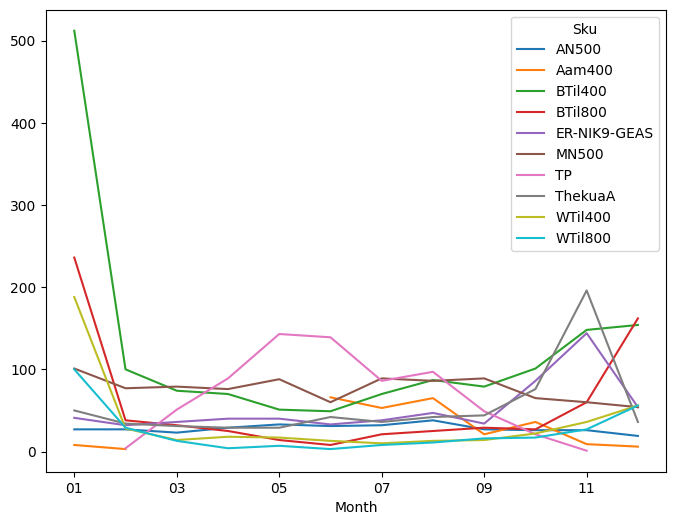

In [170]:
pivot.plot(figsize=(8,6))

Analysing what products are most often sold together

In [171]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05,2026,1996.0,411045.0,PUNE,MAHARASHTRA
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05,2026,299.0,560008.0,BENGALURU URBAN,KARNATAKA
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05,2026,499.0,400615.0,THANE,MAHARASHTRA
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05,2026,299.0,700060.0,KOLKATA,WEST BENGAL
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05,2026,299.0,700006.0,KOLKATA,WEST BENGAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101,01,2022,319.0,223101.0,JAUNPUR,UTTAR PRADESH
9970,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024,01,2022,319.0,751024.0,KHORDHA,ODISHA
9971,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123,01,2022,319.0,141123.0,LUDHIANA,PUNJAB
9972,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504,01,2022,319.0,281504.0,MATHURA,UTTAR PRADESH


In [175]:
shipment_df['Order Id']

,Order Id
0,406-9020136-5923547
1,407-7639201-4037938
2,408-5414094-4483505
3,403-7836184-2212354
4,405-7935201-1501965
...,...
9969,403-8582224-7445916
9970,405-4277916-4241966
9971,405-4829174-4689925
9972,408-6117624-4436360


In [177]:
shipment_df[shipment_df['Order Id'].duplicated(keep=False)]

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename
6,Shipment,2026-05-30 16:38:42,407-0698500-4859565,MPoha500,Savita Kitchen Mix Namkeen Poha Authentic Bi...,1,349.0,349.0,16.62,BERHAMPORE,WEST BENGAL,742101,05,2026,349.0,742101.0,MURSHIDABAD,WEST BENGAL
7,Shipment,2026-05-30 16:38:42,407-0698500-4859565,PSR400,Savita Kitchen Simple Roasted Poha 400g Auth...,1,249.0,249.0,11.86,BERHAMPORE,WEST BENGAL,742101,05,2026,249.0,742101.0,MURSHIDABAD,WEST BENGAL
9,Shipment,2026-05-29 07:59:40,408-7580897-8795525,PP,Savita Kitchen Masala Papad Rice Fresh Khich...,1,399.0,399.0,0.00,NEW DELHI,DELHI,110054,05,2026,399.0,110054.0,CENTRAL,DELHI
10,Shipment,2026-05-29 07:59:40,408-7580897-8795525,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,NEW DELHI,DELHI,110054,05,2026,299.0,110054.0,CENTRAL,DELHI
11,Shipment,2026-05-29 07:59:40,408-7580897-8795525,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,6,2994.0,2994.0,0.00,NEW DELHI,DELHI,110054,05,2026,17964.0,110054.0,CENTRAL,DELHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,Shipment,2022-01-05 00:53:12,171-3102857-6192313,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,GURUGRAM,HARYANA,122004,01,2022,319.0,122004.0,GURUGRAM,HARYANA
9949,Shipment,2022-01-04 10:30:58,402-8420277-0522768,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA
9950,Shipment,2022-01-04 10:30:58,402-8420277-0522768,WTil400,Savita Kitchen Safed Til Gud Badam Ke Ladu Wh...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA
9963,Shipment,2022-01-02 08:19:52,407-9861777-8286737,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,SIDCUL HARIDWAR,UTTARAKHAND,249403,01,2022,319.0,249403.0,HARIDWAR,UTTARAKHAND


In [178]:
df_duplicated = shipment_df[shipment_df['Order Id'].duplicated(keep=False)]

In [179]:
df_duplicated

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename
6,Shipment,2026-05-30 16:38:42,407-0698500-4859565,MPoha500,Savita Kitchen Mix Namkeen Poha Authentic Bi...,1,349.0,349.0,16.62,BERHAMPORE,WEST BENGAL,742101,05,2026,349.0,742101.0,MURSHIDABAD,WEST BENGAL
7,Shipment,2026-05-30 16:38:42,407-0698500-4859565,PSR400,Savita Kitchen Simple Roasted Poha 400g Auth...,1,249.0,249.0,11.86,BERHAMPORE,WEST BENGAL,742101,05,2026,249.0,742101.0,MURSHIDABAD,WEST BENGAL
9,Shipment,2026-05-29 07:59:40,408-7580897-8795525,PP,Savita Kitchen Masala Papad Rice Fresh Khich...,1,399.0,399.0,0.00,NEW DELHI,DELHI,110054,05,2026,399.0,110054.0,CENTRAL,DELHI
10,Shipment,2026-05-29 07:59:40,408-7580897-8795525,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,NEW DELHI,DELHI,110054,05,2026,299.0,110054.0,CENTRAL,DELHI
11,Shipment,2026-05-29 07:59:40,408-7580897-8795525,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,6,2994.0,2994.0,0.00,NEW DELHI,DELHI,110054,05,2026,17964.0,110054.0,CENTRAL,DELHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,Shipment,2022-01-05 00:53:12,171-3102857-6192313,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,GURUGRAM,HARYANA,122004,01,2022,319.0,122004.0,GURUGRAM,HARYANA
9949,Shipment,2022-01-04 10:30:58,402-8420277-0522768,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA
9950,Shipment,2022-01-04 10:30:58,402-8420277-0522768,WTil400,Savita Kitchen Safed Til Gud Badam Ke Ladu Wh...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA
9963,Shipment,2022-01-02 08:19:52,407-9861777-8286737,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,SIDCUL HARIDWAR,UTTARAKHAND,249403,01,2022,319.0,249403.0,HARIDWAR,UTTARAKHAND


In [182]:
df_duplicated.groupby(['Order Id'])['Sku'].apply(lambda x: ','.join(x)).reset_index().rename(columns={'Sku':'Grouped Products'})

,Order Id,Grouped Products
0,171-0187468-2799545,"PT400,AAM-400N,TPC200,WTil800,MN500"
1,171-0340696-6110759,"WTil800,BTil800"
2,171-0481600-3290724,"BTil400,WTil400"
3,171-0615510-2037100,"WTil800,BTil800"
4,171-0687631-4594755,"SPoha400,MPoha500"
...,...,...
457,408-8720963-7921940,"ER-NIK9-GEAS,AN900"
458,408-8908838-2171522,"JP,TPC200"
459,408-9066534-0389166,"AN500,ThekuaA"
460,408-9257974-6762704,"Tisi800,TP"


In [183]:
grp_product = df_duplicated.groupby(['Order Id'])['Sku'].apply(lambda x: ','.join(x)).reset_index().rename(columns={'Sku':'Grouped Products'})

In [185]:
grp_product_df = df_duplicated.merge(grp_product , how='left', on='Order Id')

In [186]:
grp_product_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename,Grouped Products
0,Shipment,2026-05-30 16:38:42,407-0698500-4859565,MPoha500,Savita Kitchen Mix Namkeen Poha Authentic Bi...,1,349.0,349.0,16.62,BERHAMPORE,WEST BENGAL,742101,05,2026,349.0,742101.0,MURSHIDABAD,WEST BENGAL,"MPoha500,PSR400"
1,Shipment,2026-05-30 16:38:42,407-0698500-4859565,PSR400,Savita Kitchen Simple Roasted Poha 400g Auth...,1,249.0,249.0,11.86,BERHAMPORE,WEST BENGAL,742101,05,2026,249.0,742101.0,MURSHIDABAD,WEST BENGAL,"MPoha500,PSR400"
2,Shipment,2026-05-29 07:59:40,408-7580897-8795525,PP,Savita Kitchen Masala Papad Rice Fresh Khich...,1,399.0,399.0,0.00,NEW DELHI,DELHI,110054,05,2026,399.0,110054.0,CENTRAL,DELHI,"PP,Aam4,TP,800TSR"
3,Shipment,2026-05-29 07:59:40,408-7580897-8795525,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,NEW DELHI,DELHI,110054,05,2026,299.0,110054.0,CENTRAL,DELHI,"PP,Aam4,TP,800TSR"
4,Shipment,2026-05-29 07:59:40,408-7580897-8795525,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,6,2994.0,2994.0,0.00,NEW DELHI,DELHI,110054,05,2026,17964.0,110054.0,CENTRAL,DELHI,"PP,Aam4,TP,800TSR"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,Shipment,2022-01-05 00:53:12,171-3102857-6192313,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,GURUGRAM,HARYANA,122004,01,2022,319.0,122004.0,GURUGRAM,HARYANA,"Lai350,BTil400"
1017,Shipment,2022-01-04 10:30:58,402-8420277-0522768,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA,"BTil400,WTil400"
1018,Shipment,2022-01-04 10:30:58,402-8420277-0522768,WTil400,Savita Kitchen Safed Til Gud Badam Ke Ladu Wh...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA,"BTil400,WTil400"
1019,Shipment,2022-01-02 08:19:52,407-9861777-8286737,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,SIDCUL HARIDWAR,UTTARAKHAND,249403,01,2022,319.0,249403.0,HARIDWAR,UTTARAKHAND,"BTil400,WTil400"


In [189]:
no_duplicate_grpprod= grp_product_df.drop_duplicates(subset=['Order Id'])

In [190]:
no_duplicate_grpprod

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename,Grouped Products
0,Shipment,2026-05-30 16:38:42,407-0698500-4859565,MPoha500,Savita Kitchen Mix Namkeen Poha Authentic Bi...,1,349.0,349.0,16.62,BERHAMPORE,WEST BENGAL,742101,05,2026,349.0,742101.0,MURSHIDABAD,WEST BENGAL,"MPoha500,PSR400"
2,Shipment,2026-05-29 07:59:40,408-7580897-8795525,PP,Savita Kitchen Masala Papad Rice Fresh Khich...,1,399.0,399.0,0.00,NEW DELHI,DELHI,110054,05,2026,399.0,110054.0,CENTRAL,DELHI,"PP,Aam4,TP,800TSR"
6,Shipment,2026-05-28 10:05:35,408-8720963-7921940,ER-NIK9-GEAS,Savita Kitchen Authentic Thekua Traditional ...,1,499.0,499.0,23.76,BENGALURU,KARNATAKA,560100,05,2026,499.0,560100.0,BENGALURU URBAN,KARNATAKA,"ER-NIK9-GEAS,AN900"
8,Shipment,2026-05-28 09:33:52,404-7675634-2022722,800TSR,Savita Kitchen Authentic Bihari Flax Seeds Bar...,1,499.0,499.0,23.76,Varanasi,UTTAR PRADESH,221001,05,2026,499.0,221001.0,VARANASI,UTTAR PRADESH,"800TSR,TP"
10,Shipment,2026-05-25 23:44:09,171-8993126-2464316,PSR400,Savita Kitchen Simple Roasted Poha 400g Auth...,1,249.0,249.0,11.86,Bengaluru,KARNATAKA,560076,05,2026,249.0,560076.0,BENGALURU URBAN,KARNATAKA,"PSR400,TP"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,Shipment,2022-01-05 20:26:34,403-9356064-8488341,WTil400,Savita Kitchen Safed Til Gud Badam Ke Ladu Wh...,1,319.0,319.0,15.19,HYDERABAD,TELANGANA,500090,01,2022,319.0,500090.0,MEDCHAL MALKAJGIRI,TELANGANA,"WTil400,AN500"
1012,Shipment,2022-01-05 20:06:11,171-8342644-1773162,MN500,Savita Kitchen Nimki Namkeen The Taste of ...,1,289.0,289.0,13.76,BHADRA,RAJASTHAN,335501,01,2022,289.0,335501.0,HANUMANGARH,RAJASTHAN,"MN500,ThekuaA,Lai350"
1015,Shipment,2022-01-05 00:53:12,171-3102857-6192313,Lai350,Savita Kitchen Lai Murmura Laddu Makar Sankr...,1,269.0,269.0,12.81,GURUGRAM,HARYANA,122004,01,2022,269.0,122004.0,GURUGRAM,HARYANA,"Lai350,BTil400"
1017,Shipment,2022-01-04 10:30:58,402-8420277-0522768,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,2,638.0,638.0,30.38,FARIDABAD,HARYANA,121003,01,2022,1276.0,121003.0,FARIDABAD,HARYANA,"BTil400,WTil400"


<Axes: ylabel='count'>

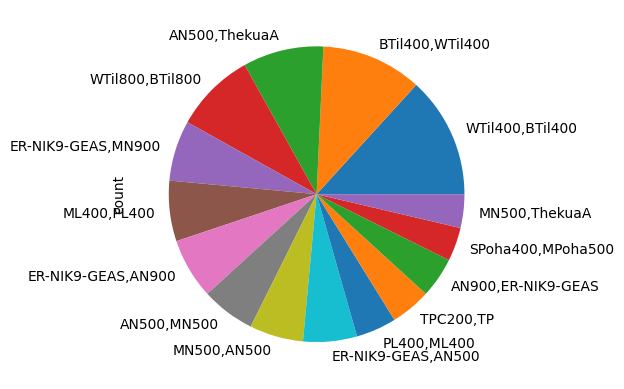

In [195]:
no_duplicate_grpprod['Grouped Products'].value_counts()[0:15].plot.pie()

When do people Buy


In [198]:
shipment_df['Hour']=pd.to_datetime(shipment_df['Order Date']).dt.hour

In [199]:
shipment_df

,Transaction Type,Order Date,Order Id,Sku,Item Description,Quantity,Invoice Amount,Principal Amount,Total Tax Amount,Ship To City,Ship To State,Ship To Postal Code,Month,Year,Sales,pincode,district,statename,Hour
0,Shipment,2026-05-31 08:30:42,406-9020136-5923547,TP,Savita Kitchen Tilauri Papad 600g Traditiona...,2,998.0,998.0,0.00,PUNE,MAHARASHTRA,411045,05,2026,1996.0,411045.0,PUNE,MAHARASHTRA,8
1,Shipment,2026-05-31 05:58:14,407-7639201-4037938,Aam4,Savita Kitchen Aam Ka Achar Traditional Biha...,1,299.0,299.0,14.24,BENGALURU,KARNATAKA,560008,05,2026,299.0,560008.0,BENGALURU URBAN,KARNATAKA,5
2,Shipment,2026-05-31 02:50:04,408-5414094-4483505,AN900,Savita Kitchen Authentic Atta Nimki 800g W...,1,499.0,499.0,23.76,THANE,MAHARASHTRA,400615,05,2026,499.0,400615.0,THANE,MAHARASHTRA,2
3,Shipment,2026-05-30 20:59:38,403-7836184-2212354,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,KOLKATA,WEST BENGAL,700060,05,2026,299.0,700060.0,KOLKATA,WEST BENGAL,20
4,Shipment,2026-05-30 20:54:21,405-7935201-1501965,MN500,Savita Kitchen Authentic Maida Nimki Namak Pa...,1,299.0,299.0,14.24,Kolkata,WEST BENGAL,700006,05,2026,299.0,700006.0,KOLKATA,WEST BENGAL,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,Shipment,2022-01-01 17:34:36,403-8582224-7445916,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,Shahganj,UTTAR PRADESH,223101,01,2022,319.0,223101.0,JAUNPUR,UTTAR PRADESH,17
9970,Shipment,2022-01-01 13:52:09,405-4277916-4241966,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,BHUBANESWAR,ODISHA,751024,01,2022,319.0,751024.0,KHORDHA,ODISHA,13
9971,Shipment,2022-01-01 10:14:14,405-4829174-4689925,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,LUDHIANA,PB,141123,01,2022,319.0,141123.0,LUDHIANA,PUNJAB,10
9972,Shipment,2022-01-01 04:46:38,408-6117624-4436360,BTil400,Savita Kitchen Kale Til Gud Ke Ladoo Black Se...,1,319.0,319.0,15.19,MATHURA,UTTAR PRADESH,281504,01,2022,319.0,281504.0,MATHURA,UTTAR PRADESH,4


<Axes: xlabel='Hour'>

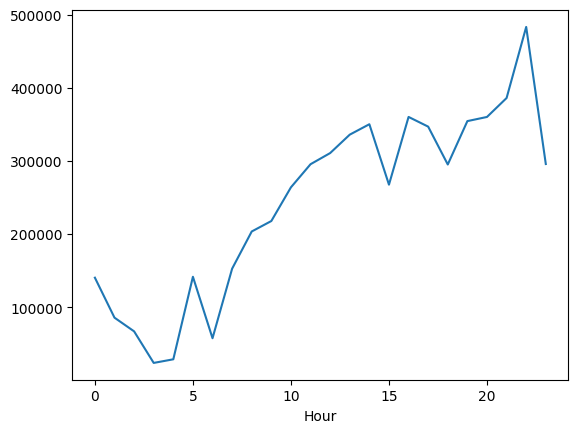

In [201]:
shipment_df.groupby('Hour')['Sales'].sum().plot()

In [202]:
shipment_df.columns

Index(['Transaction Type', 'Order Date', 'Order Id', 'Sku', 'Item Description',
       'Quantity', 'Invoice Amount', 'Principal Amount', 'Total Tax Amount',
       'Ship To City', 'Ship To State', 'Ship To Postal Code', 'Month', 'Year',
       'Sales', 'pincode', 'district', 'statename', 'Hour'],
      dtype='object')

In [205]:
shipment_df['district']

,district
0,PUNE
1,BENGALURU URBAN
2,THANE
3,KOLKATA
4,KOLKATA
...,...
9969,JAUNPUR
9970,KHORDHA
9971,LUDHIANA
9972,MATHURA


In [207]:
pivot= shipment_df.pivot_table(index='Hour', columns='district', values='Sales', aggfunc='sum')

In [208]:
import seaborn as sns

In [209]:
pivot

district,24 PARAGANAS NORTH,24 PARAGANAS SOUTH,ADILABAD,AGAR MALWA,AGRA,AHMADABAD,AHMEDNAGAR,AIZAWL,AJMER,ALAPPUZHA,...,WEST GARO HILLS,WEST GODAVARI,WEST KAMENG,WEST SINGHBHUM,West Tripura,Y.S.R.,YADADRI BHUVANAGIRI,YADGIR,YAMUNANAGAR,YAVATMAL
Hour,,,,,,,,,,,,,,,,,,,,,
0,2095.0,NaN,NaN,NaN,NaN,1466.0,598.0,NaN,NaN,748.0,...,NaN,NaN,NaN,NaN,NaN,NaN,349.0,NaN,NaN,NaN
1,499.0,598.0,NaN,NaN,199.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,499.0,1217.0,NaN,NaN,NaN,NaN,NaN,299.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,798.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,1197.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,499.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,349.0,NaN,NaN,NaN,NaN,798.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,598.0,349.0,NaN,NaN,449.0,1670.0,199.0,499.0,NaN,NaN,...,NaN,NaN,NaN,NaN,399.0,NaN,NaN,NaN,NaN,NaN
8,3778.0,349.0,299.0,NaN,NaN,3190.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='district', ylabel='Hour'>

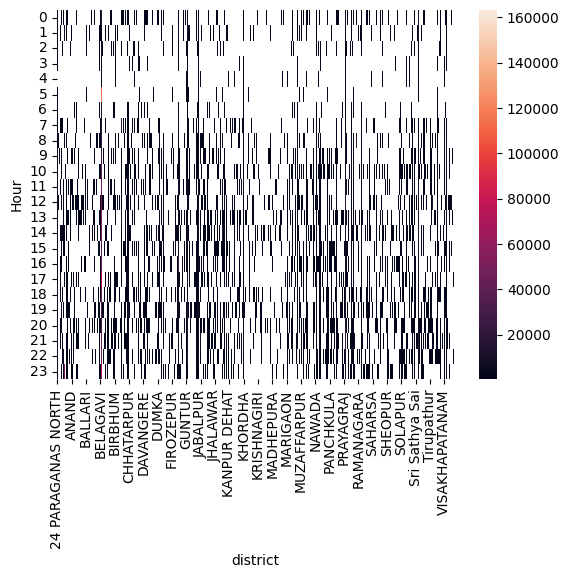

In [210]:
sns.heatmap(pivot)

In [211]:
import plotly.express as px

In [212]:
fig= px.imshow(pivot,
          x=pivot.columns,
          y=pivot.index,
          title= "Hourly Heatmap Sales by Cities",
          color_continuous_scale="Inferno")

In [213]:
fig